# Bike Sharing Analysis

Proyek ini menggunakan Bike Sharing Dataset harian (`day.csv`) dan per jam (`hour.csv`) untuk periode 2011-2012.
Fokus analisis: pola permintaan berdasarkan hari, cuaca, dan jam, serta implikasinya untuk operasional.
Output utama mencakup pertanyaan bisnis, temuan EDA, visualisasi, dan rekomendasi tindakan.

## Pertanyaan Bisnis (SMART)

Pertanyaan disusun agar spesifik, terukur, berorientasi aksi, relevan, dan berbatas waktu (2011-2012).
1. **Bagaimana perbedaan rata-rata jumlah penyewaan harian antara hari kerja dan hari libur/akhir pekan pada periode 2011-2012?**
2. **Bagaimana kondisi cuaca memengaruhi rata-rata jumlah penyewaan harian pada periode 2011-2012?**
3. **Pada jam berapa terjadi puncak penyewaan dan bagaimana perbedaannya antara hari kerja vs libur/akhir pekan selama 2011-2012?**

Setiap pertanyaan akan dijawab dengan metrik rata-rata dan didukung visualisasi yang memandu keputusan operasional.

### Import Library
Library yang dipakai mencakup:
- `pandas` dan `numpy` untuk manipulasi data dan perhitungan statistik,
- `matplotlib` dan `seaborn` untuk visualisasi eksploratif.
Kombinasi ini cukup untuk seluruh alur: wrangling, EDA, dan visualisasi.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset
Memuat dua dataset:
- `day.csv` untuk analisis pola harian,
- `hour.csv` untuk pola per jam.
Langkah ini juga memeriksa beberapa baris awal agar struktur dan tipe data dapat diverifikasi.

In [11]:
df_day = pd.read_csv('data/day.csv')
df_hour = pd.read_csv('data/hour.csv')

df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

df_day.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Data Wrangling

Tahap ini memastikan data siap dianalisis dan bebas masalah besar.
Ruang lingkup:
- **Gathering**: memuat data ke DataFrame.
- **Assessing**: memeriksa kualitas data (missing, duplikasi, nilai tidak valid, outlier).
- **Cleaning**: memperbaiki temuan dan menambah fitur yang diperlukan untuk analisis.
Hasil wrangling menjadi fondasi seluruh EDA dan visualisasi.

### Assess Data Quality
Pemeriksaan kualitas dilakukan pada data harian dan per jam dengan fokus:
- **Missing values**: total dan per kolom,
- **Duplicate rows**: indikasi duplikasi data,
- **Invalid values**: nilai di luar rentang yang masuk akal (mis. skala 0-1),
- **Outlier** pada `cnt` menggunakan metode IQR.
Ringkasan ini menentukan langkah cleaning yang perlu dilakukan.

In [12]:
missing_values_day = df_day.isna().sum()
duplicate_count_day = df_day.duplicated().sum()

missing_values_hour = df_hour.isna().sum()
duplicate_count_hour = df_hour.duplicated().sum()

range_checks = {
    'season': (1, 4),
    'yr': (0, 1),
    'mnth': (1, 12),
    'holiday': (0, 1),
    'weekday': (0, 6),
    'workingday': (0, 1),
    'weathersit': (1, 4),
    'temp': (0, 1),
    'atemp': (0, 1),
    'hum': (0, 1),
    'windspeed': (0, 1),
    'casual': (0, None),
    'registered': (0, None),
    'cnt': (0, None),
}

invalid_counts_day = {}
for col, (min_val, max_val) in range_checks.items():
    if max_val is None:
        invalid_counts_day[col] = (df_day[col] < min_val).sum()
    else:
        invalid_counts_day[col] = ((df_day[col] < min_val) | (df_day[col] > max_val)).sum()

q1, q3 = df_day['cnt'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_count_day = ((df_day['cnt'] < lower_bound) | (df_day['cnt'] > upper_bound)).sum()

assessment_summary = pd.DataFrame({
    'dataset': ['day', 'hour'],
    'missing_values_total': [missing_values_day.sum(), missing_values_hour.sum()],
    'duplicate_rows': [duplicate_count_day, duplicate_count_hour],
    'cnt_outliers': [outlier_count_day, np.nan],
})
assessment_summary

pd.DataFrame({
    'missing_values': missing_values_day,
    'invalid_count': pd.Series(invalid_counts_day)
}).fillna(0).astype(int).T


,atemp,casual,cnt,dteday,holiday,hum,instant,mnth,registered,season,temp,weathersit,weekday,windspeed,workingday,yr
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
invalid_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Cleaning dan Feature Engineering
Langkah pembersihan dan penyiapan fitur meliputi:
- menghapus duplikasi bila ditemukan,
- membuat label kategori musim dan cuaca agar mudah dibaca,
- menambahkan fitur waktu (tahun, bulan, nama bulan),
- membuat label hari kerja vs libur/akhir pekan.
Fitur ini diperlukan untuk agregasi dan perbandingan yang konsisten.

In [13]:
df_clean = df_day.copy()
if duplicate_count_day > 0:
    df_clean = df_clean.drop_duplicates()

season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow',
}

df_clean['season_label'] = df_clean['season'].map(season_map)
df_clean['weather_label'] = df_clean['weathersit'].map(weather_map)
df_clean['year'] = df_clean['dteday'].dt.year
df_clean['month'] = df_clean['dteday'].dt.month
df_clean['month_name'] = df_clean['dteday'].dt.strftime('%b')
df_clean['workingday_label'] = df_clean['workingday'].map({1: 'Working Day', 0: 'Holiday/Weekend'})

df_hour_clean = df_hour.copy()
if duplicate_count_hour > 0:
    df_hour_clean = df_hour_clean.drop_duplicates()

df_hour_clean['season_label'] = df_hour_clean['season'].map(season_map)
df_hour_clean['weather_label'] = df_hour_clean['weathersit'].map(weather_map)
df_hour_clean['year'] = df_hour_clean['dteday'].dt.year
df_hour_clean['month'] = df_hour_clean['dteday'].dt.month
df_hour_clean['month_name'] = df_hour_clean['dteday'].dt.strftime('%b')
df_hour_clean['workingday_label'] = df_hour_clean['workingday'].map({1: 'Working Day', 0: 'Holiday/Weekend'})

df_clean.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,windspeed,casual,registered,cnt,season_label,weather_label,year,month,month_name,workingday_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,0.160446,331,654,985,Spring,Mist/Cloudy,2011,1,Jan,Holiday/Weekend
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,0.248539,131,670,801,Spring,Mist/Cloudy,2011,1,Jan,Holiday/Weekend
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,0.248309,120,1229,1349,Spring,Clear,2011,1,Jan,Working Day
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,0.160296,108,1454,1562,Spring,Clear,2011,1,Jan,Working Day
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,0.186900,82,1518,1600,Spring,Clear,2011,1,Jan,Working Day


## Exploratory Data Analysis (EDA)

EDA dilakukan untuk menjawab pertanyaan bisnis secara kuantitatif.
Analisis berfokus pada:
- perbedaan rata-rata hari kerja vs libur,
- dampak cuaca terhadap permintaan,
- pola musiman per bulan,
- pola permintaan per jam (puncak dan perbedaannya).

### EDA Aggregations
Agregasi utama yang dihitung:
- rata-rata penyewaan per tipe hari (workingday vs holiday/weekend),
- rata-rata penyewaan per kondisi cuaca,
- tren rata-rata bulanan per tahun,
- rata-rata per jam untuk membandingkan hari kerja vs libur.
Hasil agregasi menjadi input untuk visualisasi dan interpretasi.

In [14]:
workingday_avg = df_clean.groupby('workingday_label', as_index=False)['cnt'].mean()
weather_avg = df_clean.groupby('weather_label', as_index=False)['cnt'].mean().sort_values('cnt', ascending=False)
monthly_trend = df_clean.groupby(['year', 'month', 'month_name'], as_index=False)['cnt'].mean()

hourly_trend = (
    df_hour_clean.groupby(['hr', 'workingday_label'], as_index=False)['cnt']
    .mean()
    .sort_values(['workingday_label', 'hr'])
 )

workingday_avg, weather_avg.head(), monthly_trend.head(), hourly_trend.head()


(  workingday_label          cnt
 0  Holiday/Weekend  4330.168831
 1      Working Day  4584.820000,
      weather_label          cnt
 0            Clear  4876.786177
 2      Mist/Cloudy  4035.862348
 1  Light Snow/Rain  1803.285714,
    year  month month_name          cnt
 0  2011      1        Jan  1231.903226
 1  2011      2        Feb  1721.964286
 2  2011      3        Mar  2065.967742
 3  2011      4        Apr  3162.333333
 4  2011      5        May  4381.322581,
    hr workingday_label        cnt
 0   0  Holiday/Weekend  90.800000
 2   1  Holiday/Weekend  69.508696
 4   2  Holiday/Weekend  53.171053
 6   3  Holiday/Weekend  25.775330
 8   4  Holiday/Weekend   8.264317)

## Visualization & Explanatory Analysis

Visualisasi dibuat agar perbandingan mudah dibaca dan mendukung keputusan.
Prinsip yang digunakan: urutan kategori konsisten, judul dan sumbu jelas, serta label nilai.

Analisis lanjutan: **binning/manual grouping** untuk membagi level permintaan (Low/Medium/High) tanpa algoritma machine learning.

### Visual 1: Working Day vs Holiday
Tujuan: membandingkan rata-rata penyewaan pada hari kerja dan libur/akhir pekan.
Interpretasi: jika selisih besar, maka alokasi armada dan promosi harus disesuaikan berdasarkan tipe hari.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26900\2979714182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


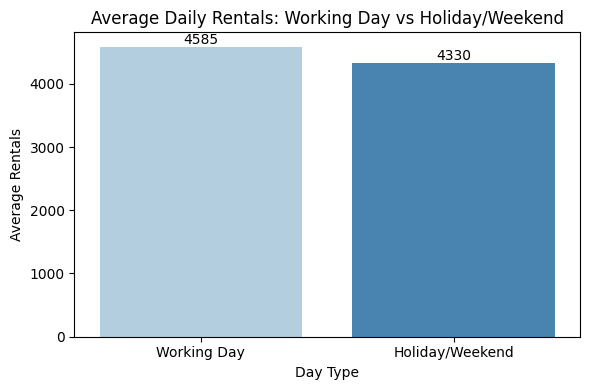

In [15]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=workingday_avg,
    x='workingday_label',
    y='cnt',
    order=['Working Day', 'Holiday/Weekend'],
    palette='Blues',
)
plt.title('Average Daily Rentals: Working Day vs Holiday/Weekend')
plt.xlabel('Day Type')
plt.ylabel('Average Rentals')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()

### Visual 2: Weather Impact
Tujuan: menilai seberapa kuat pengaruh cuaca terhadap permintaan harian.
Interpretasi: cuaca buruk biasanya menekan permintaan, sehingga dibutuhkan strategi operasional yang berbeda.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26900\2959166819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


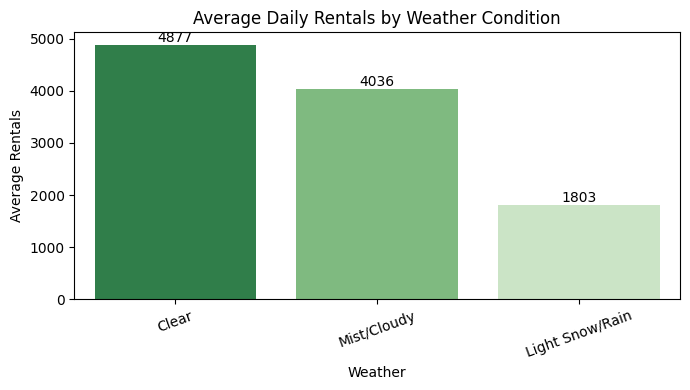

In [16]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=weather_avg,
    x='weather_label',
    y='cnt',
    order=weather_avg['weather_label'],
    palette='Greens_r',
)
plt.title('Average Daily Rentals by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Average Rentals')
plt.xticks(rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()

### Visual 3: Monthly Trend
Tujuan: menampilkan pola musiman rata-rata penyewaan per bulan untuk 2011-2012.
Interpretasi: bulan dengan permintaan tinggi menjadi prioritas kesiapan armada dan maintenance.

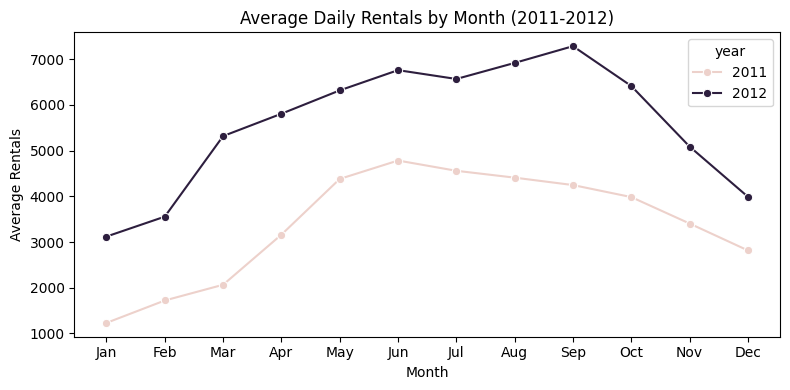

In [17]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_trend['month_name'] = pd.Categorical(
    monthly_trend['month_name'],
    categories=month_order,
    ordered=True,
)
monthly_trend = monthly_trend.sort_values(['year', 'month_name'])
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=monthly_trend,
    x='month_name',
    y='cnt',
    hue='year',
    marker='o',
    sort=False,
    hue_order=sorted(monthly_trend['year'].unique()),
)
plt.title('Average Daily Rentals by Month (2011-2012)')
plt.xlabel('Month')
plt.ylabel('Average Rentals')
plt.tight_layout()
plt.show()

### Advanced Analysis: Demand Binning
Metode: membagi `cnt` menjadi tiga kelompok (Low/Medium/High) menggunakan quantile.
Tujuan: memberikan segmentasi sederhana untuk memahami distribusi hari dengan permintaan rendah hingga tinggi.

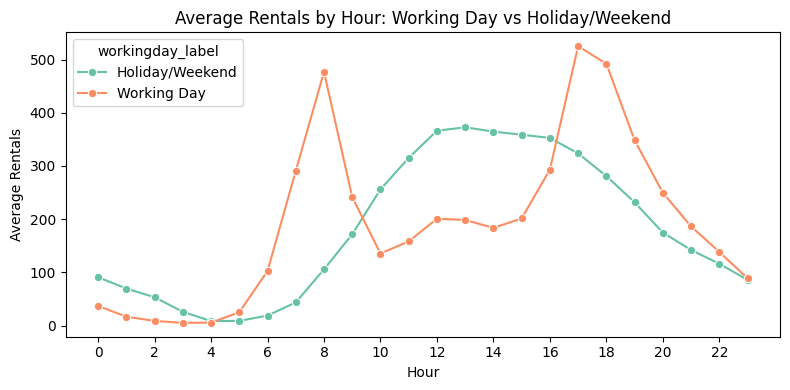

In [18]:
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=hourly_trend,
    x='hr',
    y='cnt',
    hue='workingday_label',
    marker='o',
    palette='Set2',
)
plt.title('Average Rentals by Hour: Working Day vs Holiday/Weekend')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


### Visual 4: Hourly Demand Pattern
Tujuan: menampilkan pola permintaan per jam dan membandingkan hari kerja vs libur/akhir pekan.
Interpretasi: jam puncak menjadi fokus penjadwalan armada dan operasional harian.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26900\2895883090.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=demand_counts.index, y=demand_counts.values, palette='Purples')


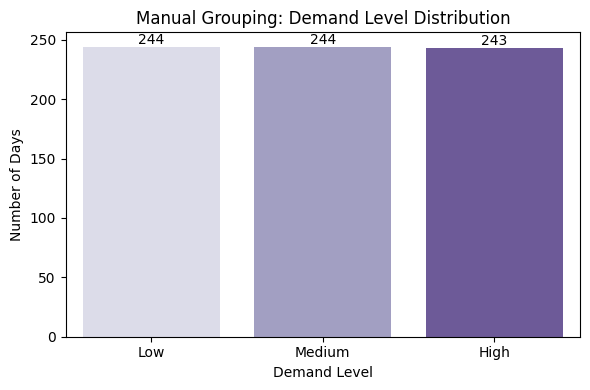

In [19]:
df_clean['demand_level'] = pd.qcut(df_clean['cnt'], q=3, labels=['Low', 'Medium', 'High'])
demand_counts = df_clean['demand_level'].value_counts().reindex(['Low', 'Medium', 'High'])

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=demand_counts.index, y=demand_counts.values, palette='Purples')
plt.title('Manual Grouping: Demand Level Distribution')
plt.xlabel('Demand Level')
plt.ylabel('Number of Days')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

**Kesimpulan:**
- Rata-rata penyewaan lebih tinggi pada hari kerja, menunjukkan dominasi penggunaan untuk aktivitas rutin.
- Kondisi cuaca berpengaruh kuat; cuaca cerah meningkatkan permintaan, cuaca buruk menurunkan jumlah penyewaan.
- Pola per jam memperlihatkan jam puncak yang berbeda antara hari kerja dan libur/akhir pekan.

**Rekomendasi:**
- Prioritaskan ketersediaan armada pada hari kerja dan saat cuaca cerah, serta siapkan rencana efisiensi saat cuaca buruk.
- Sesuaikan distribusi armada dengan jam puncak agar layanan tetap responsif.